In [1]:
from gensim.test.utils import datapath, get_tmpfile
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec
from gensim.utils import simple_preprocess
import pandas as pd
import random

In [211]:
class Spymaster():

# Load embeddings
  
    def __init__(self,color,blue,red,neutral,assassin,all,model):
        self.blue = blue
        self.red = red
        self.neutral = neutral
        self.assassin = assassin
        if color.lower() == 'red':
            self.color = red
            self.opposite = blue
        else:
            self.color = blue
            self.opposite = red
        self.all = all
    

        self.model = model
        #print(self.color)
    
    

    def PickTwo(self):
        #make similarity matrix of remaining words
        words = self.color
        #print(words)
# Filter words that are actually in the vocabulary
        words_in_vocab = [w for w in words if w in self.model.key_to_index]

# Get embeddings
        embeddings = np.array([self.model[w] for w in words_in_vocab])

# Normalize embeddings
        norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
        normalized_embeddings = embeddings / norms

# Compute cosine similarity matrix
        cosine_sim_matrix = np.dot(normalized_embeddings, normalized_embeddings.T)
        cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=words_in_vocab, columns=words_in_vocab)
# Display
        #print("Words:", words_in_vocab)
        #print("Cosine similarity matrix:\n")
        cosine_sim_df
        words = self.color
        pairs = []
        remaining_words = set(words)

        while remaining_words:
    # Take the first remaining word
            w = remaining_words.pop()
    
    # Find the word most similar to w among remaining words
    # Filter to only words still unpaired
            candidates = list(remaining_words)
        #print(candidates)
            if not candidates:
            #break
                return [w]
            #break
            sim_scores = cosine_sim_df.loc[w, candidates]
            best_match = sim_scores.idxmax()
    
    # Form a pair and remove the matched word from remaining
            pairs.append((w, best_match))
            remaining_words.remove(best_match)

        #print("Pairs based on highest similarity:")
        for p in pairs:
            print(p)
            return p
        
#     def ProvideClue(self,pair):
# #For n = 2, most similar words to both the chosen words (cluer)
#     #words = ["casino", "church"]
#         n = len(pair)
#         pair = [w.lower() for w in pair]
#     #print(pair)

# # Make sure all words are in the model
#         words_in_vocab = [w for w in pair if w in self.model.key_to_index]

#         if not words_in_vocab:
#             print("None of the words are in GloVe vocabulary.")
#         else:
#     # Find top 5 words most similar to BOTH words, weight against other words
#             #similar_words = self.model.most_similar(positive=words_in_vocab, topn=5)
#             similar_words = self.model.most_similar(positive=words_in_vocab,
#                     negative = list(self.assassin), topn=5)
#         #makes it so plurals aren't used as clues
#             for i in pair:
#                 for y in similar_words:
#                     if i in y[0]:
#                         similar_words.remove(y)
            
            
#             print('Clue: ' + str(similar_words[:1][0][0]) +' '+ str(n))
#             #print(similar_words[:1], len(pair))
#             #return similar_words[:1], len(pair)
#             return similar_words[:1][0][0], n
    

    def is_valid_clue(self,word,pair):
        url_pattern = re.compile(r"(http|www|\.com|\.org|\.net)")
        return (
            word.isalpha() and                  # only letters
            len(word) > 2 and                   # avoid short junk
            not url_pattern.search(word) and    # remove URLs/domains
            word not in pair and                # not identical to targets
            word not in self.assassin           # not assassin word
        )




    
    def ProvideClue2(self, pair):

        n = len(pair)
        pair = [w.lower() for w in pair]

    # --- lexical filter ---
        



    # Ensure words exist in vocab
        words_in_vocab = [w for w in pair if w in self.model.key_to_index]

        if not words_in_vocab:
            print("None of the words are in GloVe vocabulary.")
            return None

    # Ask for more results than needed (since we will filter)
        raw_similar = self.model.most_similar(
            positive=words_in_vocab,
            negative=list(self.assassin),
            topn=50
        )

    # Apply filtering safely
        filtered = [
            (word, score)
            for word, score in raw_similar
            if self.is_valid_clue(word,pair)
        ]
        for i in pair:
            for y in filtered:
                if i in y[0]:
                    filtered.remove(y)


        if not filtered:
            print("No valid clue found after filtering.")
            return None

        clue = filtered[0][0]

        print(f"Clue: {clue} {n}")
        return clue, n

    

    def ProvideClue3(self, pair):
        n = len(pair)
        pair = [w.lower() for w in pair]

        ASSASSIN_PENALTY = 2.0  # tune this — default gensim uses 1.0

        words_in_vocab = [w for w in pair if w in self.model.key_to_index]
        if not words_in_vocab:
            print("None of the words are in GloVe vocabulary.")
            return None

        assassin_word = list(self.assassin)[0].lower()

        raw_candidates = self.model.most_similar(positive=words_in_vocab, topn=200)

        def score_candidate(word):
            vec = self.model[word]
            pos_sim = np.mean([
                np.dot(vec, self.model[w]) / (np.linalg.norm(vec) * np.linalg.norm(self.model[w]))
                for w in words_in_vocab
            ])
            assassin_sim = np.dot(vec, self.model[assassin_word]) / (
                np.linalg.norm(vec) * np.linalg.norm(self.model[assassin_word])
            ) if assassin_word in self.model.key_to_index else 0

            return pos_sim - (ASSASSIN_PENALTY * assassin_sim)

        scored = [
            (word, score_candidate(word))
            for word, _ in raw_candidates
            if self.is_valid_clue(word, pair) and not any(i in word for i in pair)
        ]

        for i in pair:
            scored = [(word, s) for word, s in scored if i not in word]

        scored.sort(key=lambda x: x[1], reverse=True)

        if not scored:
            print("No valid clue found after filtering.")
            return None

        clue = scored[0][0]
        print(f"Clue: {clue} {n}")
        return clue, n

In [ ]:
class Operative():

    def __init__(self,color,blue,red,neutral,assassin,all,model):
        self.all = all
        self.blue = blue
        self.red = red
        self.neutral = neutral
        self.assassin = assassin
        if color.lower() == 'red':
            self.color = self.red
        else:
            self.color = self.blue
        self.model = model
        
    
    def Guesser(self,target_word, n):
    #Guesser, only receives target word from cluer and can only select from all 25 words
   
        candidate_words = [w.lower() for w in self.all]
        candidates_in_vocab = [w for w in candidate_words if w in self.model.key_to_index]


        target_vec = self.model[target_word]  # vector for target word

# Compute cosine similarity with each candidate
        similarities = {}
        for w in candidates_in_vocab:
            candidate_vec = self.model[w]
    # cosine similarity: dot(u,v) / (||u|| * ||v||)
            sim = np.dot(target_vec, candidate_vec) / (np.linalg.norm(target_vec) * np.linalg.norm(candidate_vec))
            similarities[w] = sim

# Sort candidates by similarity descending
        sorted_candidates = sorted(similarities.items(), key=lambda x: x[1], reverse=True)
        guess = []
        for i in sorted_candidates[:n]:
            guess.append(i[0])
# Show top 5
        print(sorted_candidates[:n])
        return(guess)
    


In [13]:
class Game():
    def __init__(self,color,blue,red,neutral,assassin,all):
        color = color.lower()
        self.blue = blue
        self.red = red
        self.neutral = neutral
        self.assassin = assassin
        self.all = all
        if color.lower() == 'red':
            self.color = self.red
            self.opposite = self.blue
        else:
            self.color = self.blue
            self.opposite = self.red
        self.c = color
        colors = set(['blue','red'])
        self.opp = colors.difference(set([color]))
        self.score = {'Team Guess':0,'Opposite Guess':0,'Neutral Guess':0,'Assassin Guess':0}
        self.n = []

    
    #Score func: +1 for team guess, -1 for other team, -0.2 for neutral, -0.5 for assassin


    # def CheckGuess(self,guess):
    #     for i in guess:
    #         print(i)
    #         if i in self.blue:
    #             print(f'{i}: Correct!')
    #             self.blue.remove(i)
    #         if i in self.red:
    #             print(f'Incorrect! {i} is red')
    #             self.red.remove(i)
    #         if i in self.neutral:
    #             print(f'Incorrect! {i} is Neutral!')
    #             self.neutral.remove(i)
    #         if i in self.assassin:
    #             print(f'Incorrect! {i} is the Assassin')
    #             print('Game Over')

    def CheckGuess2(self,guess):
        for i in guess:
            print(i)
            if i in self.color:
                print(f'{i}: Correct!')
                self.color.remove(i)
                self.all.remove(i)
                self.score['Team Guess'] +=1
            if i in self.opposite:
                print(f'Incorrect! {i} is {self.opp}')
                self.opposite.remove(i)
                self.all.remove(i)
                self.score['Opposite Guess'] +=1
                break
            if i in self.neutral:
                print(f'Incorrect! {i} is Neutral!')
                self.neutral.remove(i)
                self.all.remove(i)
                self.score['Neutral Guess']+=1
                break
            if i in self.assassin:
                print(f'Incorrect! {i} is the Assassin')
                print('Game Over')
                self.score['Assassin Guess'] +=1
                return 'assassin'
                break
        print('\n')
        print(f'Blue: {self.blue}')
        print(f'Red: {self.red}')
        print(f'Neutral: {self.neutral}')

In [192]:
def CodeNames(blue_spy,blue_op,blue_game,red_spy,red_op,red_game,one = False):
    round = 1

    while round > 0:
        print(round)
        if round%2 == 1:
        #spy master
            if len(blue_game.color) == 0:
                print('Blue wins!')
                break
            choices = blue_spy.PickTwo()
            clue = blue_spy.ProvideClue3(choices)
            guess = blue_op.Guesser(clue[0],clue[1])
            blue_game.n.append(clue[1])
            t = blue_game.CheckGuess2(guess)
            if t == 'assassin':
                print('Assassin! Red Wins!')
                break
            round+=1
        #check
            if len(blue_game.color) == 0:
                print('Blue wins!')
                break
        
        if one:
            round+=1

            #round +=1
        print('\n')
        print(round)
        if round%2 == 0:
        #red turn
            if len(red_game.color) == 0:
                print('Red wins!')
                break
            choices = red_spy.PickTwo()
            clue = red_spy.ProvideClue3(choices)
            guess = red_op.Guesser(clue[0],clue[1])
            red_game.n.append(clue[1])
            t = red_game.CheckGuess2(guess)
            if t == 'assassin':
                print('Assassin! Blue Wins!')
                break
            round+=1
        #if len()
    
            if len(red_game.color) == 0:
                print('Red wins!')
                break
    return blue_game.score, red_game.score

In [6]:
def GameWords(words,seed = 42):
    random.seed(seed)
    rand = random.sample(range(0,394), k = 25)
    blue = []
    for i in rand[0:8]:
        blue.append(words[i])
    red = []
    for i in rand[8:17]:
        red.append(words[i])
    assassin = [words[17]]

    neutral = []
    for i in rand[18:]:
        neutral.append(words[i])
    all = blue + red + neutral + assassin

    return set(all), set(blue), set(red), set(neutral), set(assassin)

In [7]:
#GloVe Model itself
import numpy as np
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

glove_path = "/Users/chasemcgill/DSC_253/HW-1/glove.6B/glove.6B.100d.txt"
tmp_file = get_tmpfile("test_word2vec.txt")
# Convert GloVe to word2vec format (needed by gensim)
glove_input_file = glove_path
word2vec_output_file = tmp_file
glove2word2vec(glove_input_file, word2vec_output_file)

# Load embeddings
model = KeyedVectors.load_word2vec_format(word2vec_output_file, binary=False)

/var/folders/0g/r5q1qnts04zcsg_qc2q9y3380000gn/T/ipykernel_36211/1303963038.py:11: DeprecationWarning: Call to deprecated `glove2word2vec` (KeyedVectors.load_word2vec_format(.., binary=False, no_header=True) loads GLoVE text vectors.).
  glove2word2vec(glove_input_file, word2vec_output_file)


In [150]:
with open('/Users/chasemcgill/Downloads/cm_wordlist.txt', 'r') as f:
    lines_stripped = [line.strip() for line in f]
words = [item.lower() for item in lines_stripped]

all, blue, red, neutral, assassin= GameWords(words,1)


blue_spy = Spymaster('blue',blue,red,neutral,assassin,all,model)
blue_op = Operative('blue',blue,red,neutral,assassin,all,model)
blue_game = Game('blue',blue,red,neutral,assassin,all)


red_spy = Spymaster('red',blue,red,neutral,assassin,all,model)
red_op = Operative('red',blue,red,neutral,assassin,all,model)
red_game = Game('red',blue,red,neutral,assassin,all)

c = CodeNames(blue_spy, blue_op, blue_game, red_spy, red_op, red_game)


1
('cell', 'wind')
[('cells', 0.5581895709037781), ('solar', 0.5575051307678223), ('vibrations', 0.554297924041748), ('noise', 0.5406867861747742), ('waves', 0.5402930378913879), ('sunlight', 0.5214456915855408), ('radiation', 0.5068982839584351), ('speeds', 0.5065932273864746), ('currents', 0.5046910047531128), ('surface', 0.5031498074531555), ('electromagnetic', 0.5015320777893066), ('heat', 0.5014241337776184), ('winds', 0.493449866771698), ('sleep', 0.4923020303249359), ('knots', 0.4886937141418457), ('vibration', 0.4848997890949249), ('powered', 0.4844861924648285), ('beam', 0.4834999144077301), ('causes', 0.48327136039733887), ('intensity', 0.4804772436618805), ('propagation', 0.47787904739379883), ('light', 0.47557955980300903), ('sensors', 0.47552046179771423), ('particle', 0.4751250147819519), ('velocity', 0.47401702404022217), ('speed', 0.4733995199203491), ('devices', 0.4707949459552765), ('lasers', 0.47023242712020874), ('photovoltaic', 0.4691118597984314), ('dust', 0.46891

In [147]:
blue_team_guess =[]
red_team_guess = []

blue_count = {'Team Guess':0,'Opposite Guess':0,'Neutral Guess':0,'Assassin Guess':0}
red_count = {'Team Guess':0,'Opposite Guess':0,'Neutral Guess':0,'Assassin Guess':0}

# blue_turns = 0
# red_turns = 0

blue_turns = []
red_turns = []

for i in range(12):

    all, blue, red, neutral, assassin= GameWords(words,i)


    blue_spy = Spymaster('blue',blue,red,neutral,assassin,all,model)
    blue_op = Operative('blue',blue,red,neutral,assassin,all,model)
    blue_game = Game('blue',blue,red,neutral,assassin,all)


    red_spy = Spymaster('red',blue,red,neutral,assassin,all,model)
    red_op = Operative('red',blue,red,neutral,assassin,all,model)
    red_game = Game('red',blue,red,neutral,assassin,all)

    c = CodeNames(blue_spy,blue_op,blue_game,red_spy,red_op,red_game)

    blue_count = {k: blue_count[k] + c[0][k] for k in c[0]}
    red_count = {k: red_count[k] + c[1][k] for k in c[1]}

    blue_turns.append(sum(c[0].values()))
    red_turns.append(sum(c[1].values()))


    blue_team_guess.append(list(c[0].values()))
    red_team_guess.append(list(c[1].values()))  


1
('link', 'well')
Clue: connections 2
[('link', 0.7534303), ('well', 0.511654)]
link
link: Correct!
well
well: Correct!


Blue: {'pass', 'fish', 'plane', 'marble', 'bat', 'mine'}
Red: {'kiwi', 'ghost', 'drop', 'wave', 'scale', 'paper', 'pistol', 'hand', 'church'}
Neutral: {'shakespeare', 'slip', 'figure', 'club', 'heart', 'tie', 'port'}


2
Clue: 9-mm 1
[('pistol', 0.6051592)]
pistol
pistol: Correct!


Blue: {'pass', 'fish', 'plane', 'marble', 'bat', 'mine'}
Red: {'kiwi', 'ghost', 'drop', 'wave', 'scale', 'paper', 'hand', 'church'}
Neutral: {'shakespeare', 'slip', 'figure', 'club', 'heart', 'tie', 'port'}
3
('fish', 'bat')
Clue: balls 2
[('bat', 0.6811745), ('slip', 0.55905586)]
bat
bat: Correct!
slip
Incorrect! slip is Neutral!


Blue: {'pass', 'fish', 'plane', 'marble', 'mine'}
Red: {'kiwi', 'ghost', 'drop', 'wave', 'scale', 'paper', 'hand', 'church'}
Neutral: {'shakespeare', 'figure', 'club', 'heart', 'tie', 'port'}


4
('kiwi', 'ghost')
Clue: fairies 2
[('ghost', 0.42301854), ('ki

# Testing Suite Words

In [8]:
import all_boards
import copy


In [9]:
def TestWords(l):
    all = l
    blue = l[:8]
    red = l[8:17]
    assassin = l[17]
    neutral = l[18:]

    return all,blue,red,neutral,assassin

In [233]:
level = []
run_time = []
blue_acc = []
red_acc = []
blue_a = []
red_a = []
bt = []
rt = []
blue_clues = []
red_clues = []

boards = {1:copy.deepcopy(all_boards.level1),2:copy.deepcopy(all_boards.level2),3:copy.deepcopy(all_boards.level3),
4:copy.deepcopy(all_boards.level4),5:copy.deepcopy(all_boards.level5),6:copy.deepcopy(all_boards.level6),7:copy.deepcopy(all_boards.level7),
8:copy.deepcopy(all_boards.level8),9:copy.deepcopy(all_boards.level9),10:copy.deepcopy(all_boards.level10)}

for i in boards:

    blue_team_guess =[]
    red_team_guess = []

    blue_count = {'Team Guess':0,'Opposite Guess':0,'Neutral Guess':0,'Assassin Guess':0}
    red_count = {'Team Guess':0,'Opposite Guess':0,'Neutral Guess':0,'Assassin Guess':0}

    blue_turns = 0
    red_turns = 0

    blue_n = []
    red_n = []

    level.append(i)
    print(f'Level {i}')

    start = time.perf_counter()
    level1_copy = copy.deepcopy(all_boards.level1)

    for z in boards[i].values():

        all, blue, red, neutral, assassin= TestWords(z)


        blue_spy = Spymaster('blue',blue,red,neutral,assassin,all,model)
        blue_op = Operative('blue',blue,red,neutral,assassin,all,model)
        blue_game = Game('blue',blue,red,neutral,assassin,all)


        #red_spy = Spymaster('red',blue,red,neutral,assassin,all,model)
        #red_op = Operative('red',blue,red,neutral,assassin,all,model)
        #red_game = Game('red',blue,red,neutral,assassin,all)

        c = CodeNames(blue_spy,blue_op,blue_game,red_spy,red_op,red_game,one=True)

        blue_team_guess.append(list(c[0].values()))
        #red_team_guess.append(list(c[1].values()))  

        blue_count = {k: blue_count[k] + c[0][k] for k in c[0]}
        #red_count = {k: red_count[k] + c[1][k] for k in c[1]}

        blue_turns += sum(c[0].values())
        #red_turns += sum(c[1].values())

        blue_n = blue_n + blue_game.n
        #red_n = red_n + red_game.n
    end = time.perf_counter()

    #Run Time
    run_time.append(end-start)

    #Accuracy
    blue_acc.append(list(blue_count.values())[0]/sum(list(blue_count.values())))
    #red_acc.append(list(red_count.values())[0]/sum(list(red_count.values())))

    #Assassin Rate
    blue_a.append(blue_count['Assassin Guess']/5)
    #red_a.append(red_count['Assassin Guess']/5)

    #Avg Turns
    bt.append(blue_turns/5)
    #rt.append(red_turns/5)

    #Avg N
    blue_clues.append(np.array(blue_n).mean())
    #red_clues.append(np.array(red_n).mean())


Level 1
1
('hawk', 'eagle')
Clue: antelope 2
[('eagle', 0.4741364), ('whale', 0.4056532)]
eagle
eagle: Correct!
whale
whale: Correct!


Blue: ['cat', 'dog', 'bear', 'hawk', 'lion', 'shark']
Red: ['laser', 'satellite', 'telescope', 'microscope', 'server', 'engine', 'battery', 'robot', 'screen']
Neutral: ['chair', 'table', 'note', 'paper', 'card', 'ball', 'bell']


3
3
('hawk', 'dog')
Clue: pigs 2
[('dog', 0.53269047), ('cat', 0.5077976)]
dog
dog: Correct!
cat
cat: Correct!


Blue: ['bear', 'hawk', 'lion', 'shark']
Red: ['laser', 'satellite', 'telescope', 'microscope', 'server', 'engine', 'battery', 'robot', 'screen']
Neutral: ['chair', 'table', 'note', 'paper', 'card', 'ball', 'bell']


5
5
('shark', 'lion')
Clue: elephant 2
[('lion', 0.6701437), ('shark', 0.62096626)]
lion
lion: Correct!
shark
shark: Correct!


Blue: ['bear', 'hawk']
Red: ['laser', 'satellite', 'telescope', 'microscope', 'server', 'engine', 'battery', 'robot', 'screen']
Neutral: ['chair', 'table', 'note', 'paper', 'car

In [240]:
df = pd.DataFrame({'Level':level,'Accuracy':blue_acc, 'Assassin Rate':blue_a,
'Avg Turns':bt,'Avg Clue':blue_clues,'Run Time':run_time})

overall = pd.DataFrame({'Level':'Overall','Accuracy':[df['Accuracy'].mean()], 'Assassin Rate':df['Assassin Rate'].mean(),
'Avg Turns':df['Avg Turns'].mean(),'Avg Clue':df['Avg Clue'].mean(),'Run Time':df['Run Time'].mean()})

df = pd.concat([df,overall])
df['Accuracy'] = df['Accuracy'].round(4)
df['Avg Clue'] = df['Avg Clue'].round(2)

df



,Level,Accuracy,Assassin Rate,Avg Turns,Avg Clue,Run Time
0,1,0.9048,0.40,8.40,1.91,0.419860
1,2,0.8511,0.00,9.40,1.78,0.521190
2,3,0.8605,0.20,8.60,1.79,0.383290
3,4,0.8205,0.20,7.80,1.74,0.380065
4,5,0.7018,0.00,11.40,1.65,0.675935
5,6,0.8667,0.20,9.00,1.80,0.441644
6,7,0.8293,0.40,8.20,1.83,0.406245
7,8,0.9000,0.60,8.00,1.95,0.356223
8,9,0.8684,0.40,7.60,1.90,0.377190
9,10,0.8611,0.40,7.20,1.85,0.365681


(0.0, 1.0)

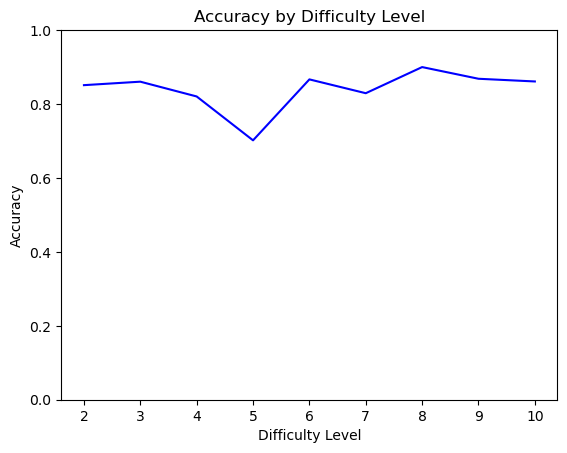

In [260]:
df = df.drop(df.index[-1])
plt.plot(df['Level'],df['Accuracy'],label = 'Accuracy', color = 'blue')
#plt.plot(df['Level'],df['Red Accuracy'],label = 'Red Accuracy', color = 'red')
#plt.legend()
plt.title('Accuracy by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Accuracy')
plt.ylim(0,1)


(0.0, 1.0)

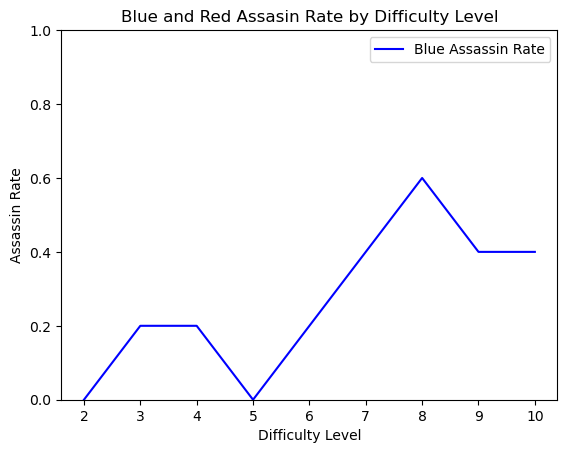

In [261]:
plt.plot(df['Level'],df['Assassin Rate'],label = 'Blue Assassin Rate', color = 'blue')
#plt.plot(df['Level'],df['Red Assassin Rate'],label = 'Red Assassin Rate', color = 'red')
plt.legend()
plt.title('Blue and Red Assasin Rate by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Assassin Rate')
plt.ylim(0,1)

(0.0, 14.0)

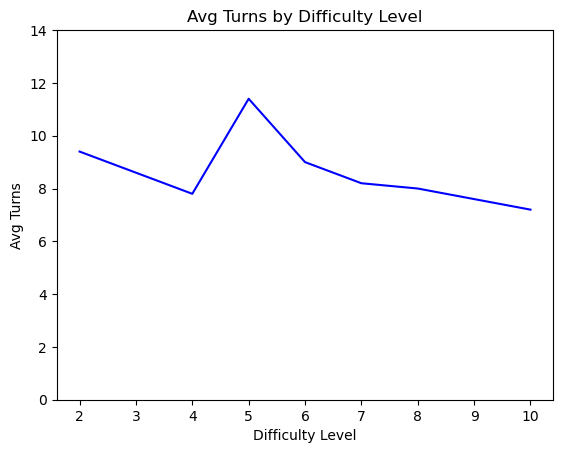

In [264]:
plt.plot(df['Level'],df['Avg Turns'],label = 'Blue Avg Turns', color = 'blue')
#plt.plot(df['Level'],df['Red Avg Turns'],label = 'Red Av Turns', color = 'red')
#plt.legend()
plt.title('Avg Turns by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Avg Turns')
plt.ylim(0,14)

(0.0, 2.5)

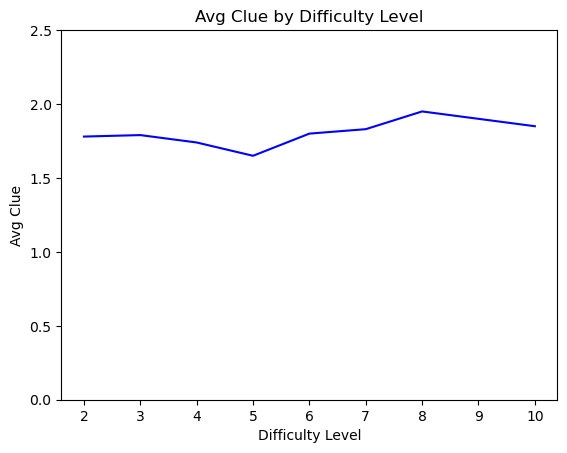

In [266]:
plt.plot(df['Level'],df['Avg Clue'],label = 'Blue Avg Clue', color = 'blue')
#plt.plot(df['Level'],df['Red Avg Clue'],label = 'Red Avg Clue', color = 'red')
#plt.legend()
plt.title('Avg Clue by Difficulty Level')
plt.xlabel('Difficulty Level')
plt.ylabel('Avg Clue')
plt.ylim(0,2.5)

(0.0, 1.0)

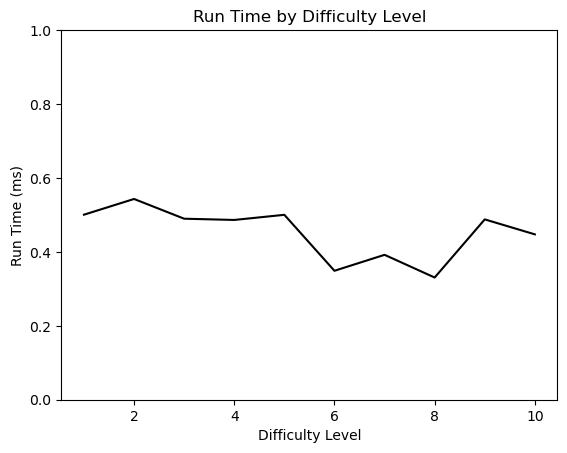

In [112]:
plt.plot(df['Level'],df['Run Time'], color = 'black')
plt.xlabel('Difficulty Level')
plt.ylabel('Run Time (ms)')
plt.title('Run Time by Difficulty Level')
plt.ylim(0,1)

In [271]:
boards = {1:copy.deepcopy(all_boards.level1),2:copy.deepcopy(all_boards.level2),3:copy.deepcopy(all_boards.level3),
4:copy.deepcopy(all_boards.level4),5:copy.deepcopy(all_boards.level5),6:copy.deepcopy(all_boards.level6),7:copy.deepcopy(all_boards.level7),
8:copy.deepcopy(all_boards.level8),9:copy.deepcopy(all_boards.level9),10:copy.deepcopy(all_boards.level10)}
len(boards[10]['10.4'])

25

In [ ]:
#For working demo

#all, blue, red, neutral, assassin= GameWords(words,3)
all, blue, red, neutral, assassin= TestWords(boards[1]['1.3'])
#1.3 is good
#5.5 for assassin
#6.4 for showing strange thought pattern


blue_spy = Spymaster('blue',blue,red,neutral,assassin,all,model)
blue_op = Operative('blue',blue,red,neutral,assassin,all,model)
blue_game = Game('blue',blue,red,neutral,assassin,all)


red_spy = Spymaster('red',blue,red,neutral,assassin,all,model)
red_op = Operative('red',blue,red,neutral,assassin,all,model)
red_game = Game('red',blue,red,neutral,assassin,all)



from codenames_adapter import CodeNames_UI
import json

game_data, blue_score, red_score = CodeNames_UI(
    blue_spy, blue_op, blue_game,
    red_spy,  red_op,  red_game
)

js = "const GAME_DATA = " + json.dumps(game_data, indent=2) + ";"
with open("game_data.js", "w") as f:
    f.write(js)

with open("codenames_ui.html", "r") as f:
    html = f.read()

# Replace the GAME_DATA block
import re
new_data = "const GAME_DATA = " + json.dumps(game_data, indent=2) + ";"
html = re.sub(r"const GAME_DATA = \{.*?\};", new_data, html, flags=re.DOTALL)

# Write it back
with open("codenames_ui.html", "w") as f:
    f.write(html)

print("Done! Open codenames_ui.html in your browser.")

('rome', 'berlin')
Clue: urbaniana 2
[('berlin', 0.16914713), ('rome', 0.1577549)]
Clue: arubans 1
[('kiwi', 0.030695088)]
('france', 'germany')
Clue: britian 2
[('france', 0.27461627), ('germany', 0.17516074)]
('olive', 'lemon')
Clue: sunsweet 2
[('pumpkin', 0.1305875), ('carrot', 0.10258311)]
('london', 'england')
Clue: berwickshire 2
[('england', 0.068536), ('london', 0.048072778)]
('olive', 'lemon')
Clue: sunsweet 2
[('nut', 0.09031162), ('lemon', 0.057512064)]
('greece', 'czech')
Clue: suleimaniyah 2
[('greece', 0.010646429), ('czech', -0.049070682)]
Done! Open codenames_ui.html in your browser.
